# Copier le Congrès US — version simple : est-ce que ça bat le marché ?

**La question, en une phrase.** Les membres du Congrès américain déclarent leurs achats d'actions. Si on les **recopie**, gagne-t-on plus que le **S&P 500** ?

On teste **deux façons** de copier, comparées au **S&P 500 (SPY)** :
- **A — tout copier** : on achète tout ce que le Congrès achète.
- **B — copier les meilleurs** : chaque année, on ne garde que les **membres les plus réguliers** (meilleur Sharpe passé) et on copie leurs achats l'année suivante.

Trois chiffres suffisent à juger : le **rendement** (CAGR), le **risque** (volatilité, pire chute), et le **rendement ajusté du risque** (Sharpe). *Notebook volontairement minimal — on raffinera ensuite.*

## 0. Préparation

On charge les achats du Congrès (2014–2026), les cours de bourse et le S&P 500, et on définit le petit moteur de backtest (repris **tel quel** du notebook 03 pour que les chiffres soient cohérents). Une seule cellule technique — tu peux la replier.

In [1]:
# ============ MOTEUR (copié du notebook 03 — ne pas modifier) ============
import os, warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

S3 = None
for base in [os.path.expanduser('~/Downloads/Jupiter'), os.path.expanduser('~/Downloads/0. Jupiter')]:
    p = Path(base) / '00. S3S4 en cours'
    if (p/'cache'/'prices').exists(): S3 = p; break
PX = S3/'cache'/'prices'; MIN_BRACKET = 1001.0

def load_transactions(min_year=2014, max_year=2026):
    df = pd.read_csv(S3/'table_congres_2014_2026.csv', dtype=str)
    df['traded']=pd.to_datetime(df['traded'],errors='coerce'); df['filed']=pd.to_datetime(df['filed'],errors='coerce')
    df['size_usd']=pd.to_numeric(df['size_usd'],errors='coerce').clip(lower=MIN_BRACKET)
    df=df[df['filed'].notna()&df['traded'].notna()]
    return df[(df['filed'].dt.year>=min_year)&(df['filed'].dt.year<=max_year)].reset_index(drop=True)
def buy_signals(df): return df[(df['op']=='buy')&df['ticker'].notna()].copy().reset_index(drop=True)
def load_panel(tickers):
    cols={}
    for t in dict.fromkeys(tickers):
        f=PX/f'{t}.csv'
        if f.exists(): cols[t]=pd.read_csv(f,index_col=0,parse_dates=True)['close']
    return pd.DataFrame(cols).sort_index()
def get_bench(name): return pd.read_csv(PX/f'{name}.csv',index_col=0,parse_dates=True)['close']

def build_sell_map(df_all):
    sells=df_all[(df_all['op']=='sell')&df_all['ticker'].notna()]
    return {k:np.sort(g['filed'].values) for k,g in sells.groupby(['bioguide','ticker'])}
def build_positions(buys, df_all, horizon_months=12, sell_map=None):
    if sell_map is None: sell_map=build_sell_map(df_all)
    H=pd.DateOffset(months=horizon_months); rows=[]
    for r in buys.itertuples(index=False):
        forced=r.filed+H; arr=sell_map.get((r.bioguide,r.ticker)); ex=forced
        if arr is not None:
            later=arr[arr>np.datetime64(r.filed)]
            if len(later): ex=min(forced,pd.Timestamp(later[0]))
        rows.append((r.bioguide,r.ticker,r.filed,ex,float(r.size_usd)))
    return pd.DataFrame(rows,columns=['bioguide','ticker','entry','exit','size_usd'])
def run_portfolio(positions, panel, weighting='size', cost_bps=20.0, lag_days=1):
    idx=panel.index; tpos={t:i for i,t in enumerate(panel.columns)}
    ret=panel.pct_change(fill_method=None).clip(-0.5,0.5).fillna(0.0).values; D,N=ret.shape
    pos=positions[positions['ticker'].isin(tpos)].copy()
    if len(pos)==0: return {'net':pd.Series(0.0,index=idx),'n_positions':0}
    if weighting=='size':       raw=pos['size_usd'].values.astype(float)
    elif weighting=='sqrt_size':raw=np.sqrt(pos['size_usd'].values.astype(float))
    else:                       raw=np.ones(len(pos))
    ei=idx.searchsorted(pos['entry'].values+np.timedelta64(lag_days,'D'),side='left')
    xi=idx.searchsorted(pos['exit'].values,side='left'); ti=pos['ticker'].map(tpos).values
    dl=np.zeros((D+1,N)); ok=ei<D
    np.add.at(dl,(ei[ok],ti[ok]),raw[ok]); np.add.at(dl,(np.clip(xi,0,D)[ok],ti[ok]),-raw[ok])
    h=np.cumsum(dl[:D],axis=0); h[h<0]=0.0; tot=h.sum(1,keepdims=True)
    w=np.divide(h,tot,out=np.zeros_like(h),where=tot>0); wp=np.vstack([np.zeros((1,N)),w[:-1]])
    gross=(wp*ret).sum(1); cost=(cost_bps/1e4)*np.abs(w-wp).sum(1)
    return {'net':pd.Series(gross-cost,index=idx),'n_positions':len(pos)}
def ann_stats(d):
    d=d.dropna(); y=len(d)/252
    return {'CAGR':(1+d).prod()**(1/y)-1,'vol':d.std()*np.sqrt(252),
            'sharpe':d.mean()/d.std()*np.sqrt(252) if d.std()>0 else np.nan,
            'maxDD':((1+d).cumprod()/(1+d).cumprod().cummax()-1).min()}
def bench_daily(price, idx): return price.reindex(idx).ffill().pct_change(fill_method=None).fillna(0.0)
def trade_returns(positions, panel, bench, lag_days=1):
    bench=bench.dropna(); out=positions.copy(); rets=[]
    for r in positions.itertuples(index=False):
        px=panel[r.ticker].dropna() if r.ticker in panel.columns else None
        if px is None or len(px)==0: rets.append(np.nan); continue
        i=px.index.searchsorted(pd.Timestamp(r.entry)+pd.Timedelta(days=lag_days)); j=min(px.index.searchsorted(pd.Timestamp(r.exit)),len(px)-1)
        if i>=len(px) or j<=i or px.iloc[i]<=0: rets.append(np.nan); continue
        rets.append(px.iloc[j]/px.iloc[i]-1.0)
    out['ret']=rets; return out
def attach_realized(buys, df, panel, bench, horizon_months=12, sell_map=None):
    pos=build_positions(buys,df,horizon_months,sell_map=sell_map); tr=trade_returns(pos,panel,bench)
    out=buys.copy(); out['traw']=tr['ret'].values; out['exit_d']=pd.to_datetime(pos['exit'].values); return out
def gate_buys(buys, selections):
    keep=[bool(selections.get(r.filed.year-1)) and r.bioguide in selections.get(r.filed.year-1,[]) for r in buys.itertuples(index=False)]
    return buys[pd.Series(keep,index=buys.index)].copy()

# ============ CHARGEMENT (une fois) ============
df   = load_transactions(2014, 2026)
buys = buy_signals(df)
panel= load_panel(buys['ticker'].dropna().unique())
SPY  = get_bench('SPY')
SELL_MAP = build_sell_map(df)
buys = attach_realized(buys, df, panel, SPY, 12, sell_map=SELL_MAP)   # ajoute 'traw' (rendt) + 'exit_d'
print(f"Univers : {len(buys):,} achats du Congres | {buys['bioguide'].nunique()} membres | {panel.shape[1]:,} titres avec cours | periode {df['filed'].dt.year.min()}-{df['filed'].dt.year.max()}")

Univers : 62,018 achats du Congres | 263 membres | 2,117 titres avec cours | periode 2014-2026


## 1. La règle du jeu (comment on « copie »)

Réaliste, sans tricher :
- **On achète le lendemain de la déclaration** (`filed + 1 jour`) — on ne peut agir qu'une fois l'information publique.
- **On revend quand le membre revend** ; s'il ne revend pas, on sort **au bout de 12 mois**.
- **Frais de 20 points de base** (0,20 %) à chaque mouvement.
- **Pondération par la taille** de la transaction déclarée.

Même règle pour les deux stratégies — seule la **liste des achats copiés** change.

## 2. Stratégie A — copier TOUT le Congrès

On réplique **tous** les achats, sans choisir. C'est le point de repère : si « tout copier » battait déjà le marché, inutile de sélectionner quoi que ce soit.

In [2]:
# Strategie A : on achete TOUT ce que le Congres achete (pondere par la taille)
spy_d = bench_daily(SPY, panel.index)
net_A = run_portfolio(build_positions(buys, df, 12, sell_map=SELL_MAP), panel, 'size', 20)['net']
tab_A = pd.DataFrame({'A - tout le Congres': ann_stats(net_A), 'S&P 500 (SPY)': ann_stats(spy_d)}).T[['CAGR','vol','sharpe','maxDD']]
print(tab_A.to_string(formatters={'CAGR':'{:+.1%}'.format,'vol':'{:.1%}'.format,'sharpe':'{:.2f}'.format,'maxDD':'{:.1%}'.format}))

                      CAGR   vol sharpe  maxDD
A - tout le Congres +13.5% 18.2%   0.79 -31.5%
S&P 500 (SPY)       +14.1% 17.0%   0.86 -33.7%


**Lecture A.** « Tout copier » fait **+13,5 %/an** (Sharpe **0,79**), contre **+14,1 %/an** pour le S&P 500 (Sharpe **0,86**). Autrement dit : **copier tout le Congrès, c'est quasiment détenir le marché** — risque comparable, mais **un cran en dessous**. Pas d'avantage.

## 3. Stratégie B — copier seulement les MEILLEURS

Peut-être que la masse dilue quelques bons. On sélectionne donc les **stars** : chaque fin d'année, on classe les membres (ayant au moins **10 trades passés**) par leur **Sharpe passé** — les plus réguliers — et on copie **les 10 meilleurs l'année suivante**. Le classement n'utilise que le passé (aucune triche sur l'avenir).

                       CAGR   vol sharpe  maxDD
A - tout le Congres  +13.5% 18.2%   0.79 -31.5%
B - les 10 meilleurs +16.2% 21.1%   0.82 -47.0%
S&P 500 (SPY)        +14.1% 17.0%   0.86 -33.7%

Robustesse (Sharpe selon le nombre de membres copies) :


   top  5 membres -> Sharpe 0.79   (S&P 500 : 0.86)


   top 10 membres -> Sharpe 0.82   (S&P 500 : 0.86)


   top 20 membres -> Sharpe 0.79   (S&P 500 : 0.86)


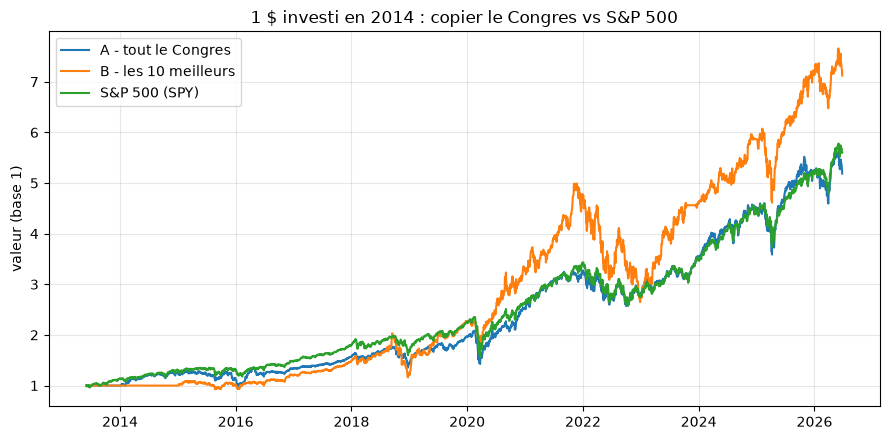

In [3]:
# Strategie B : chaque annee, garder les K membres au meilleur Sharpe passe, copier leurs achats l'annee suivante
def member_sharpe(buys, year, min_trades=10):
    past = buys[buys['exit_d'] <= pd.Timestamp(year,12,31)]
    out = {}
    for bio, g in past.groupby('bioguide'):
        r = g['traw'].dropna().values
        if len(r) >= min_trades and r.std() > 0: out[bio] = r.mean()/r.std()
    return out
def copie_meilleurs(K):
    sel = {N: [b for b,_ in sorted(member_sharpe(buys,N).items(), key=lambda x:-x[1])[:K]] for N in range(2014,2026)}
    return run_portfolio(build_positions(gate_buys(buys,sel), df, 12, sell_map=SELL_MAP), panel, 'size', 20)['net']

net_B = copie_meilleurs(10)
tab = pd.DataFrame({'A - tout le Congres': ann_stats(net_A), 'B - les 10 meilleurs': ann_stats(net_B),
                    'S&P 500 (SPY)': ann_stats(spy_d)}).T[['CAGR','vol','sharpe','maxDD']]
print(tab.to_string(formatters={'CAGR':'{:+.1%}'.format,'vol':'{:.1%}'.format,'sharpe':'{:.2f}'.format,'maxDD':'{:.1%}'.format}))
print("\nRobustesse (Sharpe selon le nombre de membres copies) :")
for K in [5,10,20]:
    print(f"   top {K:2d} membres -> Sharpe {ann_stats(copie_meilleurs(K))['sharpe']:.2f}   (S&P 500 : {ann_stats(spy_d)['sharpe']:.2f})")

# Les 3 courbes, base 1
fig, ax = plt.subplots(figsize=(9,4.5))
for lab, s in [('A - tout le Congres',net_A),('B - les 10 meilleurs',net_B),('S&P 500 (SPY)',spy_d)]:
    ax.plot(s.index, (1+s).cumprod(), label=lab)
ax.set_title("1 $ investi en 2014 : copier le Congres vs S&P 500"); ax.set_ylabel("valeur (base 1)")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

**Lecture B.** Copier les 10 meilleurs rapporte **plus** en rendement brut — **+16,2 %/an** contre +14,1 % pour le S&P 500 — **mais en prenant beaucoup plus de risque** : volatilité **21 %** (vs 17 %) et pire chute **−47 %** (vs −34 %). Une fois ce risque pris en compte, le **Sharpe (0,82) reste sous celui du S&P 500 (0,86)**. Et c'est **robuste** : qu'on copie les 5, 10 ou 20 meilleurs, on reste sous l'indice.

## 4. Verdict

| Stratégie | Rendement/an | Risque (vol) | Pire chute | Ajusté du risque (Sharpe) |
|---|---|---|---|---|
| A — tout le Congrès | +13,5 % | 18 % | −32 % | 0,79 |
| **B — les 10 meilleurs** | **+16,2 %** | **21 %** | **−47 %** | **0,82** |
| **S&P 500 (SPY)** | +14,1 % | 17 % | −34 % | **0,86** |

**Réponse : non, suivre le Congrès ne bat pas le marché à risque égal.**
- **Tout copier** ≈ le marché, un cran en dessous.
- **Copier les meilleurs** gagne un peu **plus**… mais uniquement en **prenant plus de risque** (volatilité et chutes plus fortes). Rapporté au risque, ça reste **sous le S&P 500** — et c'est vrai quel que soit le nombre de membres copiés.
- Traduction : le surplus de rendement de la sélection, c'est **du risque en plus, pas du talent**. Le moteur de la performance, c'est surtout le **marché lui-même**.

**Recommandation.** Un produit « copie du Congrès » se défend comme **pari thématique** (transparence, narratif), **pas** comme promesse de « battre le marché ». *(Le détail — tests statistiques, décompositions — est dans le notebook 03.)*